In [ ]:
!pip install -q unsloth
!pip install Pillow==11.3.0 --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.4/924.4 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import unsloth
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
from PIL import Image, ImageFilter, ImageEnhance, ImageDraw
from unsloth import FastVisionModel
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    cohen_kappa_score, classification_report, confusion_matrix
)
from scipy.optimize import curve_fit
from tqdm import tqdm

print('All imports OK')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
All imports OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path   = '/content/drive/MyDrive/Dataset'
field1_path = os.path.join(base_path, 'Field Images/FieldImages-1')
field2_path = os.path.join(base_path, 'Field Images/FieldImages-2')
lab_path    = os.path.join(base_path, 'Lab Images')

Mounted at /content/drive


In [ ]:


# Field Images 1 (CSV-annotated)
disease_cols = ['GLS','NCLB','PLS','CR','SR','NoFoliarSymptoms','Other','UnidentifiedDisease']
df1 = pd.read_csv(os.path.join(field1_path, 'Corn-Annotations.csv'))
df1['label_count'] = df1[disease_cols].sum(axis=1)
df1 = df1[df1['label_count'] == 1]
def get_label(row):
    for col in disease_cols:
        if row[col] == 1: return col
df1['label'] = df1.apply(get_label, axis=1)
df1['image_path'] = df1['filePath'].apply(lambda x: os.path.join(field1_path, 'leaf_images', x))
df1['source'] = 'field'
df1 = df1[['image_path','label','source']]

#  Field Images 2
data_field2 = []
for label in os.listdir(field2_path):
    cp = os.path.join(field2_path, label)
    if os.path.isdir(cp):
        for img in os.listdir(cp):
            data_field2.append([os.path.join(cp, img), label.upper(), 'field'])
df2 = pd.DataFrame(data_field2, columns=['image_path','label','source'])

# Lab Images
data_lab = []
for label in os.listdir(lab_path):
    cp = os.path.join(lab_path, label)
    if os.path.isdir(cp):
        for img in os.listdir(cp):
            data_lab.append([os.path.join(cp, img), label, 'lab'])
df3 = pd.DataFrame(data_lab, columns=['image_path','label','source'])

print(f'Field-1: {len(df1)} | Field-2: {len(df2)} | Lab: {len(df3)}')

Field-1: 1464 | Field-2: 1571 | Lab: 3852


In [ ]:
label_map = {
    'GLS': 'Gray_Leaf_Spot',
    'Corn_Cercospora_leaf_spot_Gray_leaf_spot': 'Gray_Leaf_Spot',
    'NCLB': 'Northern_Leaf_Blight', 'NLB': 'Northern_Leaf_Blight',
    'NLS':  'Northern_Leaf_Blight', 'Corn_Northern_Leaf_Blight': 'Northern_Leaf_Blight',
    'CR': 'Common_Rust', 'Corn_Common_rust': 'Common_Rust',
    'NoFoliarSymptoms': 'Healthy', 'Corn_healthy': 'Healthy',
    'PLS': 'Phaeosphaeria_Leaf_Spot', 'SR': 'Southern_Rust',
}
def standardise(x):
    x = str(x).strip().replace('___','_').replace(' ','_')
    return label_map.get(x, x)
for d in [df1, df2, df3]:
    d['label'] = d['label'].apply(standardise)

df_all = pd.concat([df1, df2, df3], ignore_index=True)
TARGET_CLASSES = ['Gray_Leaf_Spot','Northern_Leaf_Blight','Common_Rust','Healthy']
df_all = df_all[df_all['label'].isin(TARGET_CLASSES)].reset_index(drop=True)

print(f'Total samples (4 classes): {len(df_all)}')
print(pd.crosstab(df_all['label'], df_all['source']))

Total samples (4 classes): 6532
source                field   lab
label                            
Common_Rust             107  1192
Gray_Leaf_Spot         1153   513
Healthy                 232  1162
Northern_Leaf_Blight   1188   985


In [ ]:

df_train, df_test = train_test_split(
    df_all, test_size=0.2, random_state=42, stratify=df_all['label']
)
df_test = df_test.reset_index(drop=True)
print(f'Full test set: {len(df_test)} images')
print(df_test['label'].value_counts().to_frame('count'))

Full test set: 1307 images
                      count
label                      
Northern_Leaf_Blight    435
Gray_Leaf_Spot          333
Healthy                 279
Common_Rust             260


In [ ]:

SAMPLE_SIZE = 200

df_eval, _ = train_test_split(
    df_test, train_size=SAMPLE_SIZE, random_state=42, stratify=df_test['label']
)
df_eval = df_eval.reset_index(drop=True)

print(f'\nEvaluation sample: {len(df_eval)} images')
print(df_eval['label'].value_counts().to_frame('count'))

CLASS_NAMES  = sorted(TARGET_CLASSES)
label_to_idx = {l: i for i, l in enumerate(CLASS_NAMES)}
idx_to_label = {i: l for l, i in label_to_idx.items()}
df_eval['label_idx'] = df_eval['label'].map(label_to_idx)

eval_paths  = df_eval['image_path'].tolist()
eval_labels_str = df_eval['label'].tolist()
eval_labels_idx = df_eval['label_idx'].tolist()


Evaluation sample: 200 images
                      count
label                      
Northern_Leaf_Blight     66
Gray_Leaf_Spot           51
Healthy                  43
Common_Rust              40


In [ ]:
LORA_ADAPTER_ID = 'hamzamooraj99/AgriPath-Qwen2-VL-2B-LoRA32'

print('Loading model with Unsloth...')
model, tokenizer = FastVisionModel.from_pretrained(
    LORA_ADAPTER_ID,
    load_in_4bit=True,
    max_seq_length=2048,
)
FastVisionModel.for_inference(model)
print('Model loaded!')

Loading model with Unsloth...
==((====))==  Unsloth 2026.6.1: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found


adapter_model.safetensors:   0%|          | 0.00/232M [00:00<?, ?B/s]

Model loaded!


In [ ]:
CHOSEN_PROMPT = 'This is a corn leaf. Identify the crop and disease in this image.'

def predict_with_prompt(image_input, prompt_text):
    image = Image.open(image_input).convert('RGB') if isinstance(image_input, str) else image_input.convert('RGB')
    image.thumbnail((512, 512), Image.LANCZOS)
    messages = [{
        'role': 'user',
        'content': [{'type': 'image', 'image': image}, {'type': 'text', 'text': prompt_text}]
    }]
    input_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(image, input_text, add_special_tokens=False, return_tensors='pt').to(model.device)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=30, do_sample=False)
    input_len = inputs['input_ids'].shape[1]
    decoded = tokenizer.decode(output_ids[0, input_len:], skip_special_tokens=True).strip()
    del inputs, output_ids
    torch.cuda.empty_cache()
    return decoded

def parse_prediction(raw):
    resp = raw.lower()
    disease_text = ''
    for line in raw.split('\n'):
        if 'disease' in line.lower():
            disease_text = line.split(':')[-1].strip().lower()
            break
    if not disease_text:
        disease_text = resp

    if any(k in disease_text for k in ['gray leaf spot','grey leaf spot','gray_leaf_spot','cercospora','gls']):
        return 'Gray_Leaf_Spot'
    if any(k in disease_text for k in ['northern leaf blight','northern_leaf_blight','nlb','nclb','exserohilum','turcicum']):
        return 'Northern_Leaf_Blight'
    if any(k in disease_text for k in ['common rust','common_rust','puccinia']):
        return 'Common_Rust'
    if any(k in disease_text for k in ['healthy','no disease','none','no foliar','disease-free']):
        return 'Healthy'
    if 'rust' in disease_text and 'southern' not in disease_text:
        return 'Common_Rust'
    if 'blight' in disease_text:
        return 'Northern_Leaf_Blight'
    return 'Unknown'

def compute_all_metrics(true_str, pred_str, class_names):
    """
    Compute all required metrics. Operates on string labels.
    Unknowns are treated as a wrong prediction.
    """
    acc      = accuracy_score(true_str, pred_str)
    macro_f1 = f1_score(true_str, pred_str, average='macro',    labels=class_names, zero_division=0)
    w_f1     = f1_score(true_str, pred_str, average='weighted', labels=class_names, zero_division=0)
    prec     = precision_score(true_str, pred_str, average='macro', labels=class_names, zero_division=0)
    rec      = recall_score(true_str, pred_str, average='macro',    labels=class_names, zero_division=0)

    valid_idx = [i for i, p in enumerate(pred_str) if p != 'Unknown']
    if len(valid_idx) > 1:
        t_v = [true_str[i] for i in valid_idx]
        p_v = [pred_str[i] for i in valid_idx]
        kappa = cohen_kappa_score(t_v, p_v, labels=class_names)
    else:
        kappa = 0.0
    per_class_f1 = f1_score(true_str, pred_str, average=None, labels=class_names, zero_division=0)
    cm = confusion_matrix(true_str, pred_str, labels=class_names)
    return {
        'accuracy':     acc,
        'macro_f1':     macro_f1,
        'weighted_f1':  w_f1,
        'precision':    prec,
        'recall':       rec,
        'kappa':        kappa,
        'per_class_f1': per_class_f1.tolist(),
        'confusion_matrix': cm.tolist(),
    }

print('Helpers defined.')

Helpers defined.


In [ ]:
def gaussian_blur(img, intensity):
    return img.filter(ImageFilter.GaussianBlur(radius=intensity))

def brightness_shift(img, intensity):
    return ImageEnhance.Brightness(img).enhance(1 + intensity)

def occlusion(img, intensity):
    img = img.copy()
    w, h = img.size
    draw = ImageDraw.Draw(img)
    fraction = min(intensity / 10, 0.9)
    area = int(w * h * fraction)
    covered = 0
    rng = random.Random(42)
    while covered < area:
        rw = rng.randint(20, int(w*0.2)); rh = rng.randint(20, int(h*0.2))
        x = rng.randint(0, w-rw); y = rng.randint(0, h-rh)
        draw.rectangle([x, y, x+rw, y+rh], fill=(0,0,0))
        covered += rw * rh
    return img

def rotation(img, intensity):
    return img.rotate(intensity)

NOISE_FUNCTIONS = {
    'Gaussian_Blur':    gaussian_blur,
    'Brightness_Shift': brightness_shift,
    'Occlusion':        occlusion,
    'Rotation':         rotation,
}
INTENSITY_GRIDS = {
    'Gaussian_Blur':    [1, 3, 5, 9, 15],
    'Brightness_Shift': [-0.9, -0.6, 0.6, 0.9, 2.0],
    'Occlusion':        [1, 3, 5, 8, 10],
    'Rotation':         [15, 30, 45, 90, 100],
}
print('Noise functions defined.')

Noise functions defined.


In [ ]:
print('Running baseline evaluation (clean images)...')
preds_clean = []
for path in tqdm(eval_paths, desc='Baseline'):
    try:
        raw  = predict_with_prompt(path, CHOSEN_PROMPT)
        pred = parse_prediction(raw)
    except Exception as e:
        pred = 'Unknown'
    preds_clean.append(pred)

baseline_metrics = compute_all_metrics(eval_labels_str, preds_clean, CLASS_NAMES)

print('\n=== BASELINE RESULTS (Clean, n=200) ===')
print(f"  Accuracy:         {baseline_metrics['accuracy']:.4f}")
print(f"  Macro-F1:         {baseline_metrics['macro_f1']:.4f}")
print(f"  Weighted-F1:      {baseline_metrics['weighted_f1']:.4f}")
print(f"  Precision (macro):{baseline_metrics['precision']:.4f}")
print(f"  Recall (macro):   {baseline_metrics['recall']:.4f}")
print(f"  Cohen's Kappa:    {baseline_metrics['kappa']:.4f}")
print()
print('Per-class F1:')
for cls, f1v in zip(CLASS_NAMES, baseline_metrics['per_class_f1']):
    print(f'  {cls:<30} {f1v:.4f}')
print()
print(classification_report(eval_labels_str, preds_clean, labels=CLASS_NAMES, zero_division=0))

n_unknown = preds_clean.count('Unknown')
if n_unknown:
    print(f'Note: {n_unknown}/{len(preds_clean)} predictions were unparseable (counted as wrong).')

A0_acc      = baseline_metrics['accuracy']
A0_macro_f1 = baseline_metrics['macro_f1']

Running baseline evaluation (clean images)...


Baseline: 100%|██████████| 200/200 [11:49<00:00,  3.55s/it]


=== BASELINE RESULTS (Clean, n=200) ===
  Accuracy:         0.6700
  Macro-F1:         0.6775
  Weighted-F1:      0.6395
  Precision (macro):0.7338
  Recall (macro):   0.7234
  Cohen's Kappa:    0.5708

Per-class F1:
  Common_Rust                    0.8333
  Gray_Leaf_Spot                 0.5970
  Healthy                        0.8842
  Northern_Leaf_Blight           0.3953

                      precision    recall  f1-score   support

         Common_Rust       0.80      0.88      0.83        40
      Gray_Leaf_Spot       0.48      0.78      0.60        51
             Healthy       0.81      0.98      0.88        43
Northern_Leaf_Blight       0.85      0.26      0.40        66

           micro avg       0.67      0.67      0.67       200
           macro avg       0.73      0.72      0.68       200
        weighted avg       0.74      0.67      0.64       200

Note: 1/200 predictions were unparseable (counted as wrong).


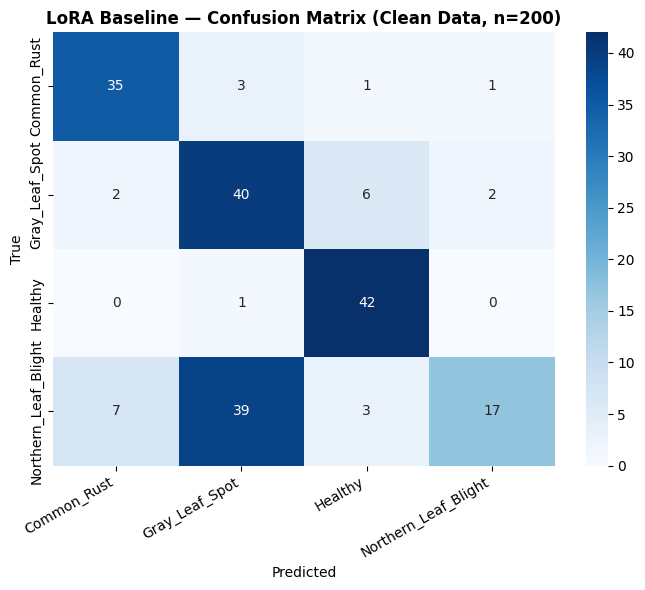

In [ ]:
# Baseline confusion matrix
cm_base = np.array(baseline_metrics['confusion_matrix'])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('LoRA Baseline — Confusion Matrix (Clean Data, n=200)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lora_confusion_baseline1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
noise_results = {}

for noise_name, noise_fn in NOISE_FUNCTIONS.items():
    noise_results[noise_name] = {}
    print(f'\n{"="*55}')
    print(f'Noise: {noise_name}  [{datetime.now().strftime("%H:%M:%S")}]')
    print(f'{"="*55}')

    for intensity in INTENSITY_GRIDS[noise_name]:
        preds = []
        for path in tqdm(eval_paths, desc=f'{noise_name} I={intensity}', leave=True):
            try:
                img   = Image.open(path).convert('RGB')
                noisy = noise_fn(img, intensity)
                raw   = predict_with_prompt(noisy, CHOSEN_PROMPT)
                pred  = parse_prediction(raw)
            except:
                pred = 'Unknown'
            preds.append(pred)

        m = compute_all_metrics(eval_labels_str, preds, CLASS_NAMES)
        m['predictions'] = preds
        noise_results[noise_name][intensity] = m

        print(f'  I={intensity:5}  acc={m["accuracy"]:.4f}  macro_f1={m["macro_f1"]:.4f}  kappa={m["kappa"]:.4f}')

    # Save after each noise type to avoid losing work
    checkpoint_save = {}
    for n, intens_dict in noise_results.items():
        checkpoint_save[n] = {}
        for intens, met in intens_dict.items():
            checkpoint_save[n][str(intens)] = {k: v for k, v in met.items() if k != 'predictions'}
    with open('/content/drive/MyDrive/lora_noise_results_checkpoint1.json', 'w') as f:
        json.dump(checkpoint_save, f, indent=2)
    print(f'  Checkpoint saved to Drive.')

print('\nAll noise evaluations complete!')


Noise: Gaussian_Blur  [12:08:29]


Gaussian_Blur I=1: 100%|██████████| 200/200 [08:37<00:00,  2.59s/it]


  I=    1  acc=0.6500  macro_f1=0.6514  kappa=0.5470


Gaussian_Blur I=3: 100%|██████████| 200/200 [08:24<00:00,  2.52s/it]


  I=    3  acc=0.5700  macro_f1=0.5556  kappa=0.4361


...

  I=   45  acc=0.6400  macro_f1=0.6430  kappa=0.5280


Rotation I=90: 100%|██████████| 200/200 [08:05<00:00,  2.43s/it]


  I=   90  acc=0.6850  macro_f1=0.6949  kappa=0.5850


Rotation I=100: 100%|██████████| 200/200 [08:08<00:00,  2.44s/it]

  I=  100  acc=0.6950  macro_f1=0.6976  kappa=0.5981
  Checkpoint saved to Drive.

All noise evaluations complete!


In [ ]:
rows = []
for noise, intensities in noise_results.items():
    for intens, m in intensities.items():
        row = {
            'Noise':       noise,
            'Intensity':   intens,
            'Accuracy':    m['accuracy'],
            'Macro_F1':    m['macro_f1'],
            'Weighted_F1': m['weighted_f1'],
            'Precision':   m['precision'],
            'Recall':      m['recall'],
            'Kappa':       m['kappa'],
        }
        for cls, f1v in zip(CLASS_NAMES, m['per_class_f1']):
            row[f'F1_{cls}'] = f1v
        rows.append(row)

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

           Noise  Intensity  Accuracy  Macro_F1  Weighted_F1  Precision   Recall    Kappa  F1_Common_Rust  F1_Gray_Leaf_Spot  F1_Healthy  F1_Northern_Leaf_Blight
   Gaussian_Blur        1.0     0.650  0.651376     0.609265   0.717725 0.712535 0.546951        0.804124           0.546875    0.913043                 0.341463
   Gaussian_Blur        3.0     0.570  0.555568     0.511253   0.683211 0.621682 0.436103        0.648649           0.535948    0.848485                 0.189189
   Gaussian_Blur        5.0     0.455  0.370085     0.361833   0.555369 0.479078 0.285458        0.086957           0.500000    0.677165                 0.216216
   Gaussian_Blur        9.0     0.360  0.268678     0.262388   0.440578 0.387701 0.175373        0.000000           0.454545    0.505882                 0.114286
   Gaussian_Blur       15.0     0.340  0.257505     0.250379   0.457738 0.369207 0.151335        0.000000           0.473118    0.469945                 0.086957
Brightness_Shift       -0.9 

In [ ]:
def exp_decay(I, k):
    return A0_macro_f1 * np.exp(-k * I)

decay_params = {}
print('Fitting A(I) = A0 * exp(-kI) on Macro-F1')
print('=' * 55)

for noise in df_results['Noise'].unique():
    df_n = df_results[df_results['Noise'] == noise].sort_values('Intensity')
    I = df_n['Intensity'].values.astype(float)
    A = df_n['Macro_F1'].values.astype(float)
    try:
        popt, _ = curve_fit(exp_decay, I, A, p0=[0.1], bounds=(0,100), maxfev=10000)
        k_fit = popt[0]
        A_pred = exp_decay(I, k_fit)
        ss_res = np.sum((A - A_pred)**2)
        ss_tot = np.sum((A - np.mean(A))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        decay_params[noise] = {'A0': A0_macro_f1, 'k': k_fit, 'R2': r2}
        print(f'{noise:<20}  A0={A0_macro_f1:.4f}  k={k_fit:.4f}  R²={r2:.4f}')
    except Exception as e:
        print(f'{noise:<20}  Fitting failed: {e}')
        decay_params[noise] = {'A0': A0_macro_f1, 'k': None, 'R2': None}

Fitting A(I) = A0 * exp(-kI) on Macro-F1
Gaussian_Blur         A0=0.6775  k=0.0865  R²=0.8880
Brightness_Shift      A0=0.6775  k=0.1513  R²=-1.3389
Occlusion             A0=0.6775  k=0.1307  R²=0.9831
Rotation              A0=0.6775  k=0.0000  R²=-0.0316


In [ ]:
THRESHOLD = 0.60
critical_thresholds = {}

print(f'Critical thresholds (Macro-F1 < {THRESHOLD})')
print('=' * 50)

for noise in df_results['Noise'].unique():
    df_n = df_results[df_results['Noise'] == noise].sort_values('Intensity')
    threshold_found = None
    for _, row in df_n.iterrows():
        if row['Macro_F1'] < THRESHOLD:
            threshold_found = row['Intensity']
            break
    critical_thresholds[noise] = threshold_found
    status = f'I = {threshold_found}' if threshold_found is not None else 'Never drops below threshold'
    print(f'{noise:<20}  {status}')

Critical thresholds (Macro-F1 < 0.6)
Gaussian_Blur         I = 3.0
Brightness_Shift      I = -0.9
Occlusion             I = 3.0
Rotation              Never drops below threshold


In [ ]:
mpc_results = {}

print('mPC Results (average drop from baseline)')
print('=' * 65)

for noise in df_results['Noise'].unique():
    df_n = df_results[df_results['Noise'] == noise]

    mpc_acc      = (A0_acc      - df_n['Accuracy']).mean()
    mpc_macro_f1 = (A0_macro_f1 - df_n['Macro_F1']).mean()

    per_class_mpc = {}
    for cls in CLASS_NAMES:
        col = f'F1_{cls}'
        baseline_cls_f1 = baseline_metrics['per_class_f1'][CLASS_NAMES.index(cls)]
        per_class_mpc[cls] = (baseline_cls_f1 - df_n[col]).mean()

    mpc_results[noise] = {
        'mPC_accuracy':  mpc_acc,
        'mPC_macro_f1':  mpc_macro_f1,
        'per_class_mpc': per_class_mpc,
    }

    print(f'\n{noise}')
    print(f'  Global mPC (Accuracy):  {mpc_acc:.4f}')
    print(f'  Global mPC (Macro-F1):  {mpc_macro_f1:.4f}')
    print('  Per-class mPC (F1 drop):')
    for cls, drop in per_class_mpc.items():
        print(f'    {cls:<30} {drop:.4f}')

mPC Results (average drop from baseline)

Gaussian_Blur
  Global mPC (Accuracy):  0.1950
  Global mPC (Macro-F1):  0.2568
  Per-class mPC (F1 drop):
    Common_Rust                    0.5254
    Gray_Leaf_Spot                 0.0949
    Healthy                        0.2013
    Northern_Leaf_Blight           0.2057

Brightness_Shift
  Global mPC (Accuracy):  0.1780
  Global mPC (Macro-F1):  0.2205
  Per-class mPC (F1 drop):
    Common_Rust                    0.3516
    Gray_Leaf_Spot                 0.1160
    Healthy                        0.2111
    Northern_Leaf_Blight           0.2031

Occlusion
  Global mPC (Accuracy):  0.2420
  Global mPC (Macro-F1):  0.3105
  Per-class mPC (F1 drop):
    Common_Rust                    0.5108
    Gray_Leaf_Spot                 0.1754
    Healthy                        0.2408
    Northern_Leaf_Blight           0.3151

Rotation
  Global mPC (Accuracy):  -0.0050
  Global mPC (Macro-F1):  -0.0037
  Per-class mPC (F1 drop):
    Common_Rust            

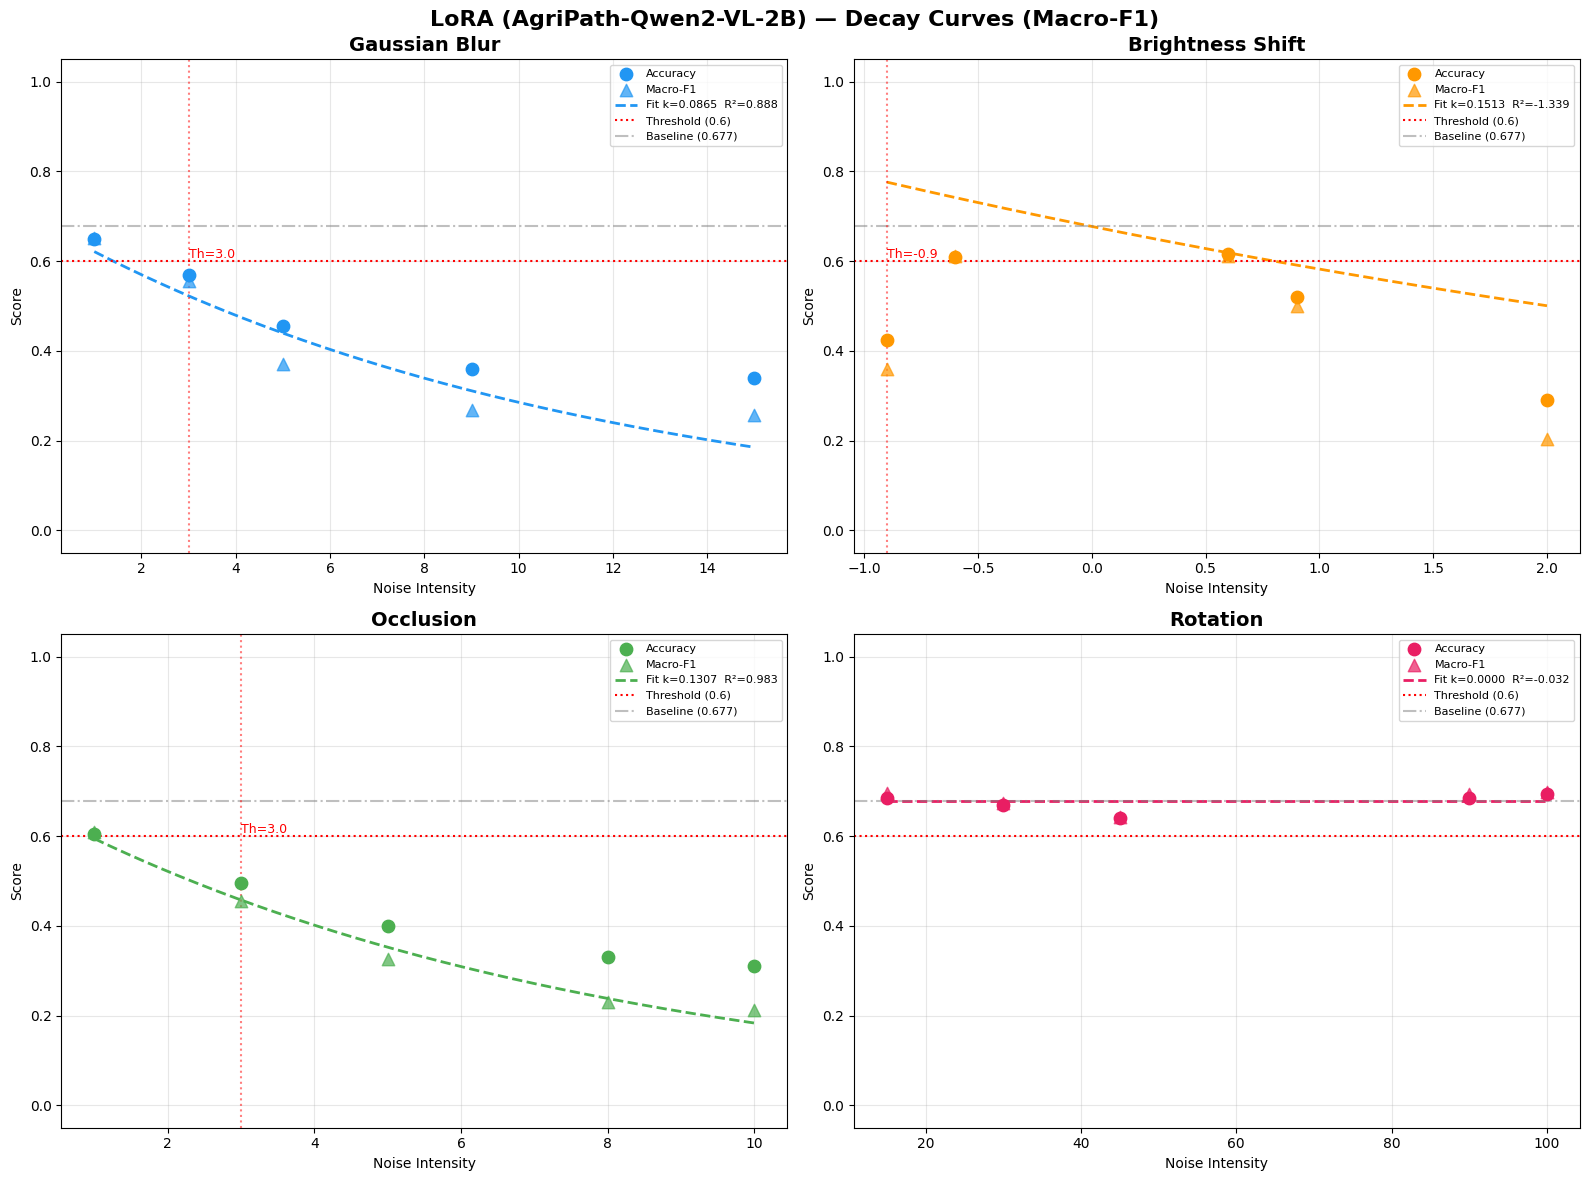

In [ ]:
COLORS = {
    'Gaussian_Blur':    '#2196F3',
    'Brightness_Shift': '#FF9800',
    'Occlusion':        '#4CAF50',
    'Rotation':         '#E91E63',
}

noise_list = list(df_results['Noise'].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LoRA (AgriPath-Qwen2-VL-2B) — Decay Curves (Macro-F1)',
             fontsize=16, fontweight='bold')

for idx, noise in enumerate(noise_list):
    ax = axes[idx//2, idx%2]
    df_n = df_results[df_results['Noise'] == noise].sort_values('Intensity')
    I  = df_n['Intensity'].values.astype(float)
    Ac = df_n['Accuracy'].values.astype(float)
    Mf = df_n['Macro_F1'].values.astype(float)
    color = COLORS[noise]

    ax.scatter(I, Ac, color=color, s=80, zorder=5, label='Accuracy')
    ax.scatter(I, Mf, color=color, s=80, marker='^', alpha=0.7, zorder=5, label='Macro-F1')

    params = decay_params[noise]
    if params['k'] is not None and params['k'] > 0:
        I_s = np.linspace(min(I), max(I), 200)
        fit = A0_macro_f1 * np.exp(-params['k'] * I_s)
        ax.plot(I_s, fit, color=color, linewidth=2, linestyle='--',
                label=f"Fit k={params['k']:.4f}  R²={params['R2']:.3f}")

    ax.axhline(y=THRESHOLD, color='red', linestyle=':', linewidth=1.5,
               label=f'Threshold ({THRESHOLD})')
    ax.axhline(y=A0_macro_f1, color='gray', linestyle='-.', alpha=0.5,
               label=f'Baseline ({A0_macro_f1:.3f})')

    th = critical_thresholds.get(noise)
    if th is not None:
        ax.axvline(x=th, color='red', linestyle=':', alpha=0.5)
        ax.annotate(f'Th={th}', xy=(th, THRESHOLD), fontsize=9, color='red',
                    ha='left', va='bottom')

    ax.set_title(noise.replace('_',' '), fontsize=14, fontweight='bold')
    ax.set_xlabel('Noise Intensity')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lora_decay_curves1.png', dpi=150, bbox_inches='tight')
plt.show()

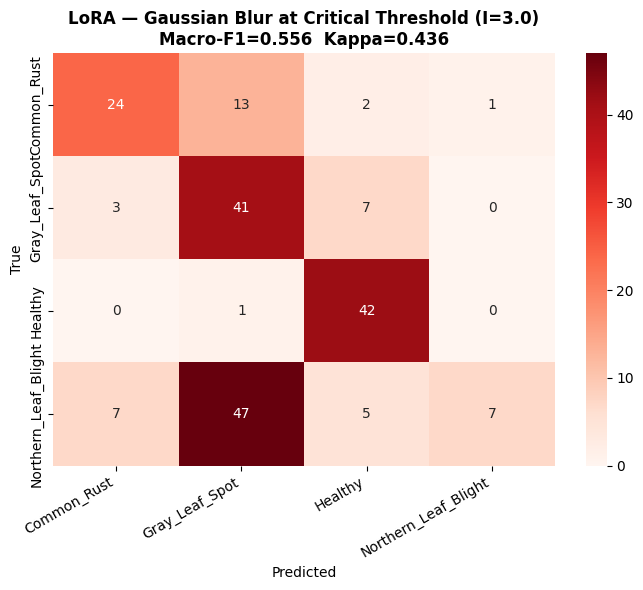

Gaussian_Blur I=3.0: Macro-F1=0.5556, Kappa=0.4361



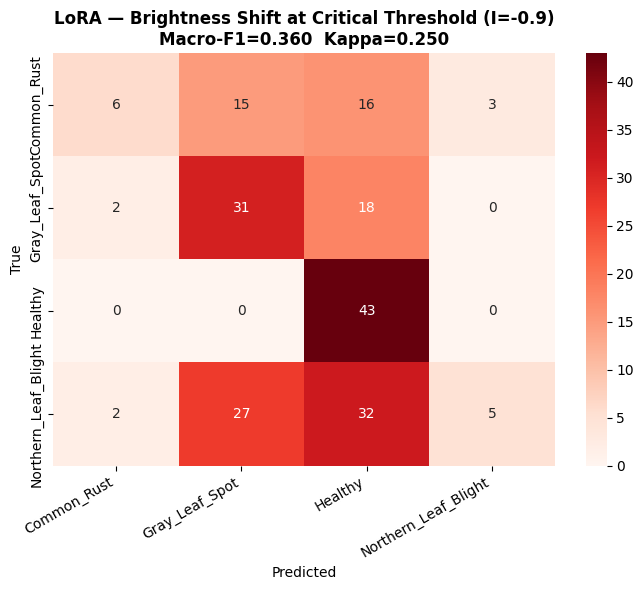

Brightness_Shift I=-0.9: Macro-F1=0.3602, Kappa=0.2499



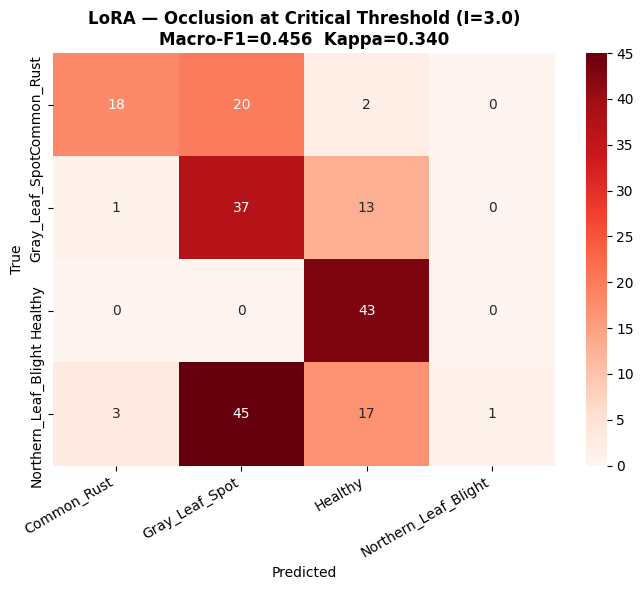

Occlusion I=3.0: Macro-F1=0.4557, Kappa=0.3405

Rotation: never reaches threshold — skipping.


In [ ]:
for noise, thresh_intensity in critical_thresholds.items():
    if thresh_intensity is None:
        print(f'{noise}: never reaches threshold — skipping.')
        continue

    m  = noise_results[noise][thresh_intensity]
    cm = np.array(m['confusion_matrix'])

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(
        f'LoRA — {noise.replace("_"," ")} at Critical Threshold (I={thresh_intensity})\n'
        f'Macro-F1={m["macro_f1"]:.3f}  Kappa={m["kappa"]:.3f}',
        fontweight='bold'
    )
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/lora_cm_{noise}_threshold1.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{noise} I={thresh_intensity}: Macro-F1={m["macro_f1"]:.4f}, Kappa={m["kappa"]:.4f}\n')

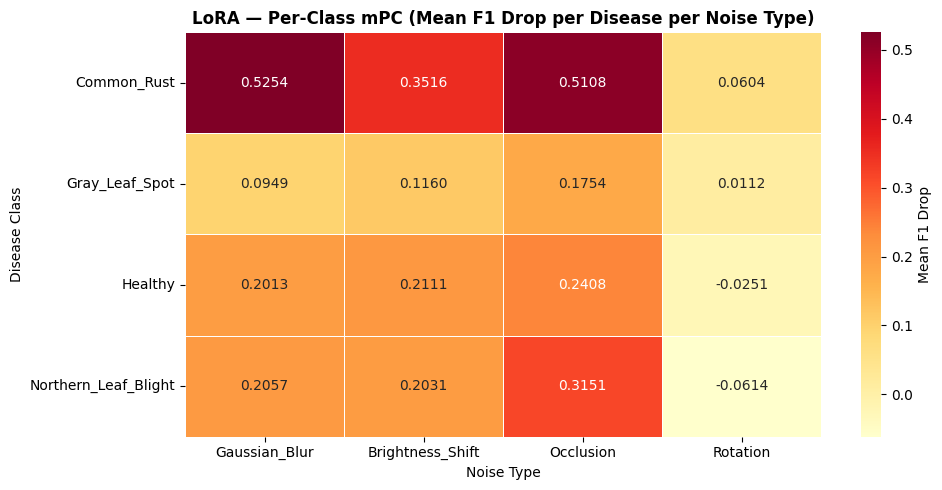


Per-class mPC table:
                      Gaussian_Blur  Brightness_Shift  Occlusion  Rotation
Common_Rust                  0.5254            0.3516     0.5108    0.0604
Gray_Leaf_Spot               0.0949            0.1160     0.1754    0.0112
Healthy                      0.2013            0.2111     0.2408   -0.0251
Northern_Leaf_Blight         0.2057            0.2031     0.3151   -0.0614


In [ ]:
noise_types  = list(mpc_results.keys())
heatmap_data = pd.DataFrame(
    {noise: [mpc_results[noise]['per_class_mpc'][cls] for cls in CLASS_NAMES]
     for noise in noise_types},
    index=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Mean F1 Drop'})
ax.set_title('LoRA — Per-Class mPC (Mean F1 Drop per Disease per Noise Type)', fontweight='bold')
ax.set_xlabel('Noise Type'); ax.set_ylabel('Disease Class')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lora_perclass_mpc1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class mPC table:')
print(heatmap_data.round(4).to_string())

In [ ]:
summary_rows = []
for noise in noise_types:
    p = decay_params[noise]
    m = mpc_results[noise]
    summary_rows.append({
        'Noise':          noise,
        'A0 (Macro-F1)':  f"{p['A0']:.4f}",
        'k (fragility)':  f"{p['k']:.4f}" if p['k'] is not None else 'N/A',
        'R²':             f"{p['R2']:.4f}" if p['R2'] is not None else 'N/A',
        'Critical Th':    critical_thresholds[noise] if critical_thresholds[noise] else 'Never',
        'mPC (Accuracy)': f"{m['mPC_accuracy']:.4f}",
        'mPC (Macro-F1)': f"{m['mPC_macro_f1']:.4f}",
    })

df_summary = pd.DataFrame(summary_rows)
print('='*90)
print('LoRA ROBUSTNESS SUMMARY')
print('='*90)
print(df_summary.to_string(index=False))

df_summary.to_csv('/content/drive/MyDrive/lora_summary1.csv', index=False)
print('\nSaved summary CSV to Drive.')

LoRA ROBUSTNESS SUMMARY
           Noise A0 (Macro-F1) k (fragility)      R² Critical Th mPC (Accuracy) mPC (Macro-F1)
   Gaussian_Blur        0.6775        0.0865  0.8880         3.0         0.1950         0.2568
Brightness_Shift        0.6775        0.1513 -1.3389        -0.9         0.1780         0.2205
       Occlusion        0.6775        0.1307  0.9831         3.0         0.2420         0.3105
        Rotation        0.6775        0.0000 -0.0316       Never        -0.0050        -0.0037

Saved summary CSV to Drive.
